In [ ]:
!python -m pop -r ../requirements.txt

In [ ]:
#이 셀에서 실행할 경우
#!python -m pop -r ../requirements.txt

#터미널에서 실행할 경우
#python -m pop -r ../requirements.txt


In [2]:
!python -m pip install beautifulsoup4


   ------------- -------------------------- 1/3 [soupsieve]
   ------------- -------------------------- 1/3 [soupsieve]
   -------------------------- ------------- 2/3 [beautifulsoup4]
   -------------------------- ------------- 2/3 [beautifulsoup4]
   -------------------------- ------------- 2/3 [beautifulsoup4]
   -------------------------- ------------- 2/3 [beautifulsoup4]
   ---------------------------------------- 3/3 [beautifulsoup4]



In [ ]:
import requests
from bs4 import BeautifulSoup

base_url = 'https://finance.naver.com/news/mainnews.naver'

response = requests.get(news_url)
status_code = response.status_code
html = response.text #응답받은 html 페이지

soup = BeautifulSoup(html, 'html.parser')
articles = soup.select('.block1')

print(status_code, len(articles))

200 20


In [16]:
articles = soup.select(".block1")
article_list = []
for article in articles:
    title = article.select_one(".articleSubject").text.strip()  #strip은 양옆 공간 잘라내는 기능
    link = article.select_one(".articleSubject > a").attrs["href"]  
    content = article.select_one(".articleSummary").contents[0].strip()
    press = article.select_one(".press").text
    date = article.select_one(".wdate").text
    
    article_list.append([title,link,content,press,date,article_list])

print(len(article_list))

20


In [ ]:
https://finance.naver.com/news/mainnews.naver
https://finance.naver.com/news/mainnews.naver?&page=2  #?는 변수가 온다는 얘기. 
https://finance.naver.com/news/mainnews.naver?&page=1  


In [20]:
import requests
import time
from bs4 import BeautifulSoup

article_list = []
base_url = 'https://finance.naver.com/news/mainnews.naver'

for page_num in range(1,6):
    news_url = f'{base_url}?&page={page_num}'
    response = requests.get(news_url)
    status_code = response.status_code
    if status_code == 200:
        html = response.text #응답받은 html 페이지

        soup = BeautifulSoup(html, 'html.parser')
        articles = soup.select('.block1')

        for article in articles:
            title = article.select_one(".articleSubject").text.strip()  #strip은 양옆 공간 잘라내는 기능
            link = article.select_one(".articleSubject > a").attrs["href"]  
            content = article.select_one(".articleSummary").contents[0].strip()
            press = article.select_one(".press").text
            date = article.select_one(".wdate").text
            
            article_list.append([title,link,content,press,date,article_list])

    else:
        print(f'Page Error {page_num}')

    time.sleep(3)

print(len(article_list))

91


In [21]:
article_list[0]

['“삼전닉스 대체 어디까지 가는 거야”…목표가 ‘55만전자 ·380만닉스’ 나왔다',
 '/news/news_read.naver?article_id=0004624951&office_id=011&mode=mainnews&type=&date=2026-05-27&page=1',
 '반토체 투톱 열기가 식을 줄 모른다. 코스피가 27일 장 초반 8450선을 터치한 가운데, 미래에셋증권은 SK하이닉스 목표주가를 기존 ..',
 '서울경제 ',
 '2026-05-27 13:10:11',
 [[...],
  ["코스피 불장, 하반기 꺾인다? '피크아웃' 불안감, 투심 영향오나",
   '/news/news_read.naver?article_id=0000098314&office_id=243&mode=mainnews&type=&date=2026-05-27&page=1',
   '최근 국내 증시의 일간 거래대금이 전고점을 갈아치우며 폭발적인 활황을 이어가고 있으나, 증권업종의 주가는 오히려 조정을 받으며 증시 체..',
   '이코노미스트 ',
   '2026-05-27 12:55:07',
   [...]],
  ['SK하이닉스, 버크셔·마이크론 제치고 글로벌 시총 12위…단일 레버리지 열기도 ‘후끈’',
   '/news/news_read.naver?article_id=0003028698&office_id=029&mode=mainnews&type=&date=2026-05-27&page=1',
   'SK하이닉스가 장중 시가총액 1조달러를 돌파하며 국내 상장사 가운데 두 번째로 ‘1조달러 클럽’에 합류했다. 인공지능(AI) 반도체 기..',
   '디지털타임스 ',
   '2026-05-27 12:52:55',
   [...]],
  ['SK하닉 10% 뛰는데 ETF는 60% 급등…"사이드카·선물 상한가 영향"',
   '/news/news_read.naver?article_id=0008968461&office_id=421&mode=mainnews&type=&date=2026

In [23]:
import requests
import time
from bs4 import BeautifulSoup

article_list = []
base_url = 'https://finance.naver.com/news/mainnews.naver'

page_num = 1
while True:
    news_url = f'{base_url}?&page={page_num}'
    response = requests.get(news_url)
    status_code = response.status_code
    if status_code == 200:
        html = response.text #응답받은 html 페이지

        soup = BeautifulSoup(html, 'html.parser')
        articles = soup.select('.block1')

        for article in articles:
            title = article.select_one(".articleSubject").text.strip()  #strip은 양옆 공간 잘라내는 기능
            link = article.select_one(".articleSubject > a").attrs["href"]  
            content = article.select_one(".articleSummary").contents[0].strip()
            press = article.select_one(".press").text
            date = article.select_one(".wdate").text
            
            article_list.append([title,link,content,press,date,article_list])

    else:
        print(f'Page Error {page_num}')
        break

    last_page_marker = article.select_one('.pgRR')
    if last_page_marker is None:
        break

    page_num += 1
    time.sleep(5)

print(len(article_list))

20


In [26]:
!python -m pip install pandas

In [24]:
!python -m pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [31]:
import pandas as pd

df = pd.DataFrame(article_list, columns = ['제목', 'URL', '요약', '언론사', '날짜', '추가칼럼'])
df.head()

,제목,URL,요약,언론사,날짜,추가칼럼
0,'반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋',/news/news_read.naver?article_id=0005363411&of...,전일 8000선에 안착한 코스피는 27일 장초반 급등하며 사상 최고가를 새로 썼다....,머니투데이,2026-05-27 13:27:04,"[['반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋', /news/news..."
1,[단독] 제이알리츠 주주들 “1450억 넣겠다”…운용사에 유증 압박,/news/news_read.naver?article_id=0002229034&of...,기업회생절차에 들어간 제이알글로벌리츠 주주들이 운용사에 1450억원 규모 유상증자를...,디지털데일리,2026-05-27 13:24:12,"[['반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋', /news/news..."
2,“삼전닉스 대체 어디까지 가는 거야”…목표가 ‘55만전자 ·380만닉스’ 나왔다,/news/news_read.naver?article_id=0004624951&of...,반토체 투톱 열기가 식을 줄 모른다. 코스피가 27일 장 초반 8450선을 터치한 ...,서울경제,2026-05-27 13:10:11,"[['반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋', /news/news..."
3,"코스피 불장, 하반기 꺾인다? '피크아웃' 불안감, 투심 영향오나",/news/news_read.naver?article_id=0000098314&of...,최근 국내 증시의 일간 거래대금이 전고점을 갈아치우며 폭발적인 활황을 이어가고 있으...,이코노미스트,2026-05-27 12:55:07,"[['반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋', /news/news..."
4,"SK하이닉스, 버크셔·마이크론 제치고 글로벌 시총 12위…단일 레버리지 열기도 ‘후끈’",/news/news_read.naver?article_id=0003028698&of...,SK하이닉스가 장중 시가총액 1조달러를 돌파하며 국내 상장사 가운데 두 번째로 ‘1...,디지털타임스,2026-05-27 12:52:55,"[['반도체 투톱' 신고가行…기업 심리 개선에 코스피 '방긋', /news/news..."


In [32]:
import openpyxl

df.to_excel("../data/finance_news.xlsx", index=False)



In [33]:
!python -m pip install selenium

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --------------------------------- ------ 8.1/9.7 MB 43.2 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 38.8 MB/s  0:00:00

   --- ------------------------------------  1/13 [websocket-client]
   --- ------------------------------------  1/13 [websocket-client]
   --- ------------------------------------  1/13 [websocket-client]
   --- ------------------------------------  1/13 [websocket-client]
   --- ------------------------------------  1/13 [websocket-client]
   --- ------------------------------------  1/13 [websocket-client]
   ------ ---------------------------------  2/13 [sniffio]
   ------------ ---------------------------  4/13 [pycparser]
   --------------- ------------------------  5/13 [h11]
   --------------- ------------------------  5/13 [h11]
   ------------------ ---------------------  6/13 [attrs]
   ------------------ ---------------------  6/13 [attrs]
   ------------

In [ ]:
news_url

'https://finance.naver.com/news/mainnews.naver?&page=1'

In [6]:
base_url = 'https://finance.naver.com/news/mainnews.naver'

In [7]:
from selenium.webdriver import Edge

driver = Edge()
driver.get(base_url)

In [8]:
from selenium.webdriver.common.by import By
elements = driver.find_elements(By.CSS_SELECTOR, '.block1')
elements

[<selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f893424fdfd90", element="f.BBAAE1C68FBA9FEEE917D469D6C43FDD.d.496FE32E73D644E62DFEA19343A68B90.e.124")>,
 <selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f893424fdfd90", element="f.BBAAE1C68FBA9FEEE917D469D6C43FDD.d.496FE32E73D644E62DFEA19343A68B90.e.125")>,
 <selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f893424fdfd90", element="f.BBAAE1C68FBA9FEEE917D469D6C43FDD.d.496FE32E73D644E62DFEA19343A68B90.e.126")>,
 <selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f893424fdfd90", element="f.BBAAE1C68FBA9FEEE917D469D6C43FDD.d.496FE32E73D644E62DFEA19343A68B90.e.127")>,
 <selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f893424fdfd90", element="f.BBAAE1C68FBA9FEEE917D469D6C43FDD.d.496FE32E73D644E62DFEA19343A68B90.e.128")>,
 <selenium.webdriver.remote.webelement.WebElement (session="605d5df7ddafefed0e2f

In [47]:
for element in elements:
    print(element.text)

코스피, 반도체 쏠림에 매수 사이드카…장 초반 고점 대비 낙폭 축소
27일 코스피가 장 초반 4%대 급등하며 사이드카까지 발동됐으나 이후 차익실현 매물이 쏟아지며 오후 들어 상승폭이 다소 줄었다. 반도체.. 이데일리 | 2026-05-27 13:34:11
'반도체 투톱' 삼전닉스 나란히 신고가…"주가 거품? 아직도 저평가"
전일 8000선에 안착한 코스피는 27일 장초반 급등하며 사상 최고가를 새로 썼다. 반도체 투톱 삼성전자와 SK하이닉스의 신고가 경신과.. 머니투데이 | 2026-05-27 13:27:04
[단독] 제이알리츠 주주들 “1450억 넣겠다”…운용사에 유증 압박
기업회생절차에 들어간 제이알글로벌리츠 주주들이 운용사에 1450억원 규모 유상증자를 요구하고 나섰다. 벨기에 자산에서 발생한 캐시트랩을.. 디지털데일리 | 2026-05-27 13:24:12
“삼전닉스 대체 어디까지 가는 거야”…목표가 ‘55만전자 ·380만닉스’ 나왔다
반토체 투톱 열기가 식을 줄 모른다. 코스피가 27일 장 초반 8450선을 터치한 가운데, 미래에셋증권은 SK하이닉스 목표주가를 기존 .. 서울경제 | 2026-05-27 13:10:11
'삼전닉스 2배' 나도 먹자…개미들 '우르르' 500조 터졌다
국내 증시에 상장된 상장지수펀드(ETF)의 시가총액이 처음으로 500조원을 넘어섰다. 코스피지수가 8000선을 돌파하며 인공지능(AI).. 한국경제 | 2026-05-27 13:06:11
코스피 불장, 하반기 꺾인다? '피크아웃' 불안감, 투심 영향오나
최근 국내 증시의 일간 거래대금이 전고점을 갈아치우며 폭발적인 활황을 이어가고 있으나, 증권업종의 주가는 오히려 조정을 받으며 증시 체.. 이코노미스트 | 2026-05-27 12:55:07
SK하이닉스, 버크셔·마이크론 제치고 글로벌 시총 12위…단일 레버리지 열기도 ‘후끈’
SK하이닉스가 장중 시가총액 1조달러를 돌파하며 국내 상장사 가운데 두 번째로 ‘1조달러 클럽’에 합류했다. 인공지능(AI) 반도체 기.. 디지털타임스

In [49]:
elements[0].find_element(By.CSS_SELECTOR, '.articleSubject').text.strip()

'코스피, 반도체 쏠림에 매수 사이드카…장 초반 고점 대비 낙폭 축소'

In [52]:
elements[0].find_element(By.CSS_SELECTOR, '.articleSubject > a').get_attribute('href')

'https://n.news.naver.com/mnews/article/018/0006291522'

In [50]:
elements[1].find_element(By.CSS_SELECTOR, '.articleSubject').text.strip()

'\'반도체 투톱\' 삼전닉스 나란히 신고가…"주가 거품? 아직도 저평가"'

In [53]:
elements[0].find_element(By.CSS_SELECTOR, '.articleSummary').text.strip()

'27일 코스피가 장 초반 4%대 급등하며 사이드카까지 발동됐으나 이후 차익실현 매물이 쏟아지며 오후 들어 상승폭이 다소 줄었다. 반도체.. 이데일리 | 2026-05-27 13:34:11'

In [55]:
elements[2].find_element(By.CSS_SELECTOR, '.articleSummary').text.strip()

'기업회생절차에 들어간 제이알글로벌리츠 주주들이 운용사에 1450억원 규모 유상증자를 요구하고 나섰다. 벨기에 자산에서 발생한 캐시트랩을.. 디지털데일리 | 2026-05-27 13:24:12'

In [56]:
elements[0].find_element(By.CSS_SELECTOR, '.press').text.strip()

'이데일리'

In [ ]:
#contentarea_left > div.mainNewsList._replaceNewsLink > ul > li:nth-child(1) > dl > dd.articleSubject

#개발자도구 > 마우스 오른쪽 > Copy > Copy selector

#contentarea_left > div.mainNewsList._replaceNewsLink > ul > li:nth-child(13) =>13번째 자식

In [57]:
elements[0].find_element(By.CSS_SELECTOR, '.wdate').text.strip()

'2026-05-27 13:34:11'

In [10]:
import time

for page_num in range(2,6):
    news_url = f'{base_url}?&page={page_num}'
    print(news_url)
    driver.get(news_url)

    elements = driver.find_elements(By.CSS_SELECTOR, '.block1')

    # for element in elements:
    #     print(element.text)

    print('=========')
    print(elements[0].find_element(By.CSS_SELECTOR, '.articleSubject').text.strip())
    print(elements[0].find_element(By.CSS_SELECTOR, '.press').text.strip())
    print(elements[0].find_element(By.CSS_SELECTOR, '.wdate').text.strip())
    print('=========')

    time.sleep(5)

https://finance.naver.com/news/mainnews.naver?&page=2
삼전닉스 목표가 줄상향에 “코스피 1만 간다” 외치는데…‘8월 정점론’도 솔솔
서울경제
2026-05-27 11:55:07
https://finance.naver.com/news/mainnews.naver?&page=3
‘지금 안 타면 진짜 거지 된다’ 삼전·닉스 레버리지, 개장 45분 만에 약 2조 몰려 [투자360]
헤럴드경제
2026-05-27 10:10:10
https://finance.naver.com/news/mainnews.naver?&page=4
“탈중앙화가 더 빠르고 싸다”…하이퍼리퀴드, 가상자산 거래소 게임체인저로
매일경제
2026-05-27 09:19:11
https://finance.naver.com/news/mainnews.naver?&page=5
KB증권 "삼성전기, MLCC 등 AI향 부품 초호황기…목표가 220만원↑"
뉴시스
2026-05-27 08:21:22


In [60]:
driver.quit()

In [61]:
driver = Edge()
driver.get('https://n.news.naver.com/mnews/article/comment/008/0005363095')

time.sleep(2)

#cbox_module > div.u_cbox_wrap.u_cbox_ko.u_cbox_type_sort_favorite > div.u_cbox_comment_count_wrap.__uis_cbox_module_countDetailWrap > ul > li:nth-child(1) > strong

In [ ]:
review_total_cnt = driver.find_element(By.CSS_SELECTOR, '.u_cbox_info_txt').text.strip()
print(review_total_cnt)  #현재 댓글 수 

56


In [ ]:
driver.find_element(By.CSS_SELECTOR, '.u_cbox_btn_more').click()
#댓글 더보기 눌러준다

In [66]:
driver.find_element(By.CSS_SELECTOR, '.u_cbox_btn_more').click()


In [67]:
driver.quit()

In [68]:
!python -m pip install playwright



   ---------------------------------------- 0.0/37.9 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/37.9 MB 33.9 MB/s eta 0:00:01
   ------------- -------------------------- 12.3/37.9 MB 35.6 MB/s eta 0:00:01
   ---------------------- ----------------- 21.0/37.9 MB 37.6 MB/s eta 0:00:01
   -------------------------------- ------- 31.2/37.9 MB 40.1 MB/s eta 0:00:01
   ---------------------------------------  37.7/37.9 MB 41.5 MB/s eta 0:00:01
   ---------------------------------------- 37.9/37.9 MB 36.6 MB/s  0:00:01

   ---------------------------------------- 0/3 [pyee]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   ------------- -------------------------- 1/3 [greenlet]
   -------------------------- ------------- 2/3 [p

In [69]:
!playwright install 

|                                                                                |   0% of 181.9 MiB
|■■■■■■■■                                                                        |  10% of 181.9 MiB
|■■■■■■■■■■■■■■■■                                                                |  20% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■                                                        |  30% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                                |  40% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                        |  50% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                                |  60% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                        |  70% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■                |  80% of 181.9 MiB
|■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■        |  90% of 

Playwright Host validation warning: Host system is missing dependencies!

Full list of missing libraries:
    msvcp140_1.dll

    at validateDependenciesWindows (c:\Users\EL022\Documents\20260522\.venv\Lib\site-packages\playwright\driver\package\lib\coreBundle.js:27719:11)
    at process.processTicksAndRejections (node:internal/process/task_queues:104:5)
    at async Registry._validateHostRequirements (c:\Users\EL022\Documents\20260522\.venv\Lib\site-packages\playwright\driver\package\lib\coreBundle.js:29205:18)
    at async Registry._validateHostRequirementsForExecutableIfNeeded (c:\Users\EL022\Documents\20260522\.venv\Lib\site-packages\playwright\driver\package\lib\coreBundle.js:29325:11)
    at async Registry.validateHostRequirementsForExecutablesIfNeeded (c:\Users\EL022\Documents\20260522\.venv\Lib\site-packages\playwright\driver\package\lib\coreBundle.js:29314:11)
    at async installBrowsers (c:\Users\EL022\Documents\20260522\.venv\Lib\site-packages\playwright\driver\package\lib\

In [ ]:
#llm이 점점 활성화되면서 에이전트 기능도 각광받으면서 playwright를 사용해보는 게 좋겠다
#그래서 플레이라이트가 어떻게 동작하는지정도는 체험해봐야 한다

# Reference [위키독스] http://wikidocs.net/231787

In [ ]:
!python -m pip install konlpy wordcloud matplotlib numpy

#konlpy는 코어가 자바다. 형태소 분석하는 도구다. 그래서 자바 openJDK설치한 것

  Using cached konlpy-0.6.0-py2.py3-none-any.whl.metadata (1.9 kB)
   ---------------------------------------- 0.0/19.4 MB ? eta -:--:--
   -------- ------------------------------- 4.2/19.4 MB 21.9 MB/s eta 0:00:01
   ---------------------------- ----------- 13.6/19.4 MB 34.3 MB/s eta 0:00:01
   ---------------------------------------- 19.4/19.4 MB 34.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 8.3/8.3 MB 60.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 52.9 MB/s  0:00:00
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 4.1/4.1 MB 52.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 56.7 MB/s  0:00:00

   ----------------------------------------  0/11 [pypars

In [13]:
!python -m pip install tqdm

In [8]:
from collections import Counter
from konlpy.tag import Okt

import os
os.environ['JAVA_HOME'] = r'C:\Program Files\Microsoft\jdk-25.0.3.9-hotspot'

#테스트용 문장
sample_text = """성전기 격전 SK스퀘어, 하닉 대안투자로 재평가 현대차, 로보틱스·피지컬 AI 기대 삼성전기, AI열풍에 실적개선 .. 헤럴드경제 | 2026-05-27 11:44:11
하루 새 조단위 들락날락…‘삼전닉스’ 레버리지 과열 주의보.. 갈아치우며 폭발적인 활황을 이어가고 있으나, 증권업종의 주가는 오히려 조정을 받으며 증시 체.. 이코노미스트 | 2026-05-27 12:55:07
SK하이닉스, 버크셔·마이크론 제치고 글로벌 시총 12위…단일 레버리지 열기도 
"""

#KoNLPy의 okt 형태소 분석기 초기화
okt = Okt()

#텍스트에서 명사만 추출하기
noun_list = okt.nouns(sample_text)

print('========== 명사 목록 ============')
print(f'총 명사 개수: {len(noun_list)}개')
print(noun_list[:15], '...(생략)')




========== 명사 목록 ============
총 명사 개수: 48개
['전기', '격전', '스퀘어', '닉', '대안', '투자', '재', '평가', '현대차', '로보틱스', '피지', '컬', '기대', '삼성', '전기'] ...(생략)


In [18]:
word_counts = Counter(noun_list)

print('=====워드 카운트 결과 (상위 5개)========')
top_words = word_counts.most_common(5)
for word, count in top_words: 
    print(f'[{word}] : {count} 회')

=====워드 카운트 결과 (상위 5개)========
[전기] : 2 회
[레버리지] : 2 회
[격전] : 1 회
[스퀘어] : 1 회
[닉] : 1 회


In [19]:
print('======의미있는 두 글자 이상 단어 (상위 5개)=======')
filtered_counts = Counter([noun for noun in noun_list if len(noun) > 1])
top_words_filtered = filtered_counts.most_common(5)
for word, count in top_words: 
    print(f'[{word}] : {count} 회')

======의미있는 두 글자 이상 단어 (상위 5개)=======
[전기] : 2 회
[레버리지] : 2 회
[격전] : 1 회
[스퀘어] : 1 회
[닉] : 1 회


In [22]:
print(len(top_words))
print(len(top_words_filtered))

5
5


In [23]:
print(len(word_counts))
print(len(filtered_counts))

46
38


In [24]:
word_counts

Counter({'전기': 2,
         '레버리지': 2,
         '격전': 1,
         '스퀘어': 1,
         '닉': 1,
         '대안': 1,
         '투자': 1,
         '재': 1,
         '평가': 1,
         '현대차': 1,
         '로보틱스': 1,
         '피지': 1,
         '컬': 1,
         '기대': 1,
         '삼성': 1,
         '열풍': 1,
         '실적': 1,
         '개선': 1,
         '헤럴드경제': 1,
         '하루': 1,
         '새': 1,
         '단위': 1,
         '들락날락': 1,
         '닉스': 1,
         '과열': 1,
         '주의보': 1,
         '폭발': 1,
         '활황': 1,
         '어가': 1,
         '증권': 1,
         '업종': 1,
         '주가': 1,
         '오히려': 1,
         '조정': 1,
         '증시': 1,
         '체': 1,
         '이코노미스트': 1,
         '하이닉스': 1,
         '버크셔': 1,
         '마이크론': 1,
         '제': 1,
         '글로벌': 1,
         '총': 1,
         '위': 1,
         '단일': 1,
         '열기': 1})

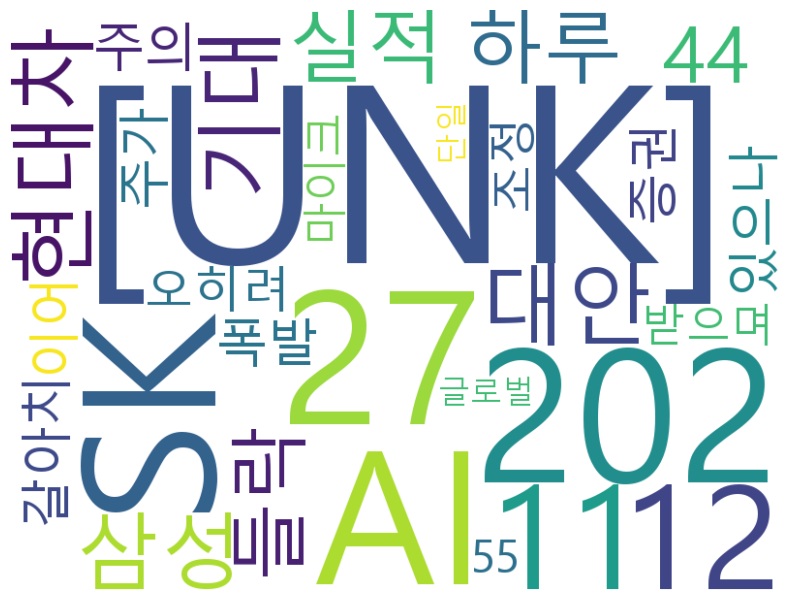

In [11]:
#차트 그리기
import matplotlib.pyplot as plt
from wordcloud import WordCloud

#Matplotlib을 위한 한글 설정(차트 제목, 축 텍스트용)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)  #마이너스 기호 깨짐 방지

#WordCloud를 위한 폰트 경로 설정(이미지 자체에 표시되기 위한 폰트)
font_path = r'C:\Windows\Fonts\malgun.ttf'
wc = WordCloud(
    font_path=font_path, 
    background_color='white', #배경색(기본값은 검정)
    width=800,
    height=600,
    max_words=100, #최대 표시할 단어 수 
    colormap='viridis', #글자 색상 테마 (맷볼립 컬러맵 참조)    
)

#빈도수 기반으로 워드 클라우드 생성
cloud = wc.generate_from_frequencies(word_counts)

#맷볼립을 사용해 화면에 출력
plt.figure(figsize=(10, 8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off') #축 눈금 숨기기
plt.show()




In [26]:
#이미지 파일 저장
cloud.to_file('../img/wordcloud_result.png')


In [ ]:
# 강사님 수업자료 가져오는 법: 파일에 오른쪽 마우스 > 추가 옵션 표시 > 
# Open git bash here (선생님자료 가져와진다) > 
# cmd 열리면 $ git pull > code . > 그러면 vs code화면까지 열린다 

In [3]:
!python -m pip install transformers torch

  Using cached transformers-5.9.0-py3-none-any.whl.metadata (33 kB)
  Using cached torch-2.12.0-cp314-cp314-win_amd64.whl.metadata (31 kB)
  Using cached huggingface_hub-1.16.4-py3-none-any.whl.metadata (14 kB)
  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.5.9-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached hf_xet-1.5.0-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.

In [4]:
from transformers import AutoTokenizer

sample_text = """성전기 격전 SK스퀘어, 하닉 대안투자로 재평가 현대차, 로보틱스·피지컬 AI 기대 삼성전기, AI열풍에 실적개선 .. 헤럴드경제 | 2026-05-27 11:44:11
하루 새 조단위 들락날락…‘삼전닉스’ 레버리지 과열 주의보.. 갈아치우며 폭발적인 활황을 이어가고 있으나, 증권업종의 주가는 오히려 조정을 받으며 증시 체.. 이코노미스트 | 2026-05-27 12:55:07
SK하이닉스, 버크셔·마이크론 제치고 글로벌 시총 12위…단일 레버리지 열기도"""

tokenizer = AutoTokenizer.from_pretrained('beomi/kcbert-base')
tokens1 = tokenizer.tokenize(sample_text)
print(tokens1)

['성', '##전', '##기', '격', '##전', 'SK', '##스', '##퀘', '##어', ',', '하', '##닉', '대안', '##투자', '##로', '재', '##평가', '현대차', ',', '로', '##보', '##틱', '##스', '·', '피', '##지', '##컬', 'AI', '기대', '삼성', '##전', '##기', ',', 'AI', '##열', '##풍', '##에', '실적', '##개선', '.', '.', '헤', '##럴', '##드', '##경제', '|', '202', '##6', '-', '0', '##5', '-', '27', '11', ':', '44', ':', '11', '하루', '새', '조', '##단위', '들락', '##날', '##락', '[UNK]', '[UNK]', '삼', '##전', '##닉', '##스', '[UNK]', '레', '##버리지', '과', '##열', '주의', '##보', '.', '.', '갈아치', '##우', '##며', '폭발', '##적인', '활', '##황', '##을', '이어', '##가고', '있으나', ',', '증권', '##업', '##종의', '주가', '##는', '오히려', '조정', '##을', '받으며', '증', '##시', '체', '.', '.', '이', '##코', '##노', '##미', '##스트', '|', '202', '##6', '-', '0', '##5', '-', '27', '12', ':', '55', ':', '0', '##7', 'SK', '##하이', '##닉', '##스', ',', '버', '##크', '##셔', '·', '마이크', '##론', '제', '##치고', '글로벌', '시', '##총', '12', '##위', '[UNK]', '단일', '레', '##버리지', '열', '##기도']


In [ ]:
#이 아래부터 따라잡아야 함

In [6]:
token1_ids = tokenizer.convert_tokens_to_ids(tokens1)
print(token1_ids)

[1856, 4203, 4184, 282, 4203, 21572, 4103, 6069, 4071, 15, 3352, 5623, 13778, 14103, 4091, 2499, 17165, 18220, 15, 1201, 4010, 5406, 4103, 97, 3343, 4102, 4723, 22502, 9298, 8527, 4203, 4184, 15, 22502, 4193, 5017, 4113, 26940, 25938, 17, 17, 3421, 4382, 4273, 8681, 93, 15289, 4539, 16, 19, 4044, 16, 18111, 10450, 29, 25958, 29, 10450, 8525, 1807, 2572, 29994, 28643, 4272, 4348, 1, 1, 1797, 4203, 5623, 4103, 1, 1171, 21269, 321, 4193, 16918, 4010, 17, 17, 24647, 4216, 4078, 14910, 8097, 3456, 4432, 4027, 10704, 8477, 19269, 15, 26042, 4210, 20830, 15947, 4008, 8937, 16612, 4027, 24810, 2680, 4039, 2886, 17, 17, 2451, 4599, 4041, 4090, 8795, 93, 15289, 4539, 16, 19, 4044, 16, 18111, 9685, 29, 24401, 29, 19, 4262, 21572, 24249, 5623, 4103, 15, 1527, 4147, 4453, 97, 23845, 4191, 2545, 8351, 14402, 2002, 4696, 9685, 4069, 1, 24375, 1171, 21269, 2275, 8517]


In [9]:
meaningful_words = []

# 워드 카운트를 위한 필터링 전처리
for token in tokens1:
    # 조사나 어미 앞에 '##' 을 붙인다.
    # '##' 으로 시작하지 않는 토큰이 원래 단어의 핵심(명사/어근) 부분이다. 
    if not token.startswith('##'):
        # 특수 문자나 한 글자짜리 조사(의, 에 등...)를 걸러내기 위해 2글자 이상만 추출
        if len(token) > 1:
            meaningful_words.append(token)

# 빈도수 계산
word_counts = Counter(meaningful_words)
word_counts_top = word_counts.most_common(5)

for word, count in word_counts_top:
    print(f'{word} : {count} 회')

[UNK] : 4 회
SK : 2 회
AI : 2 회
202 : 2 회
27 : 2 회


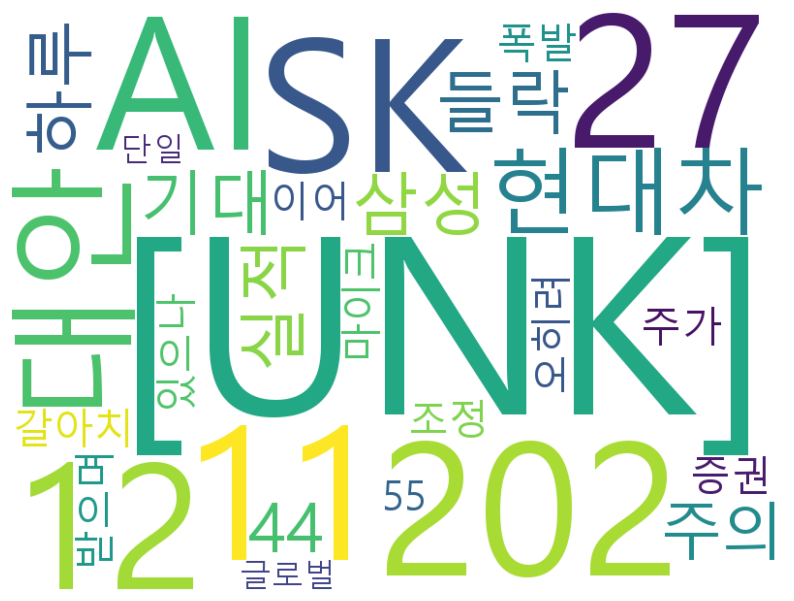

In [12]:
# 빈도수 기반으로 워드 클라우드 생성
cloud2 = wc.generate_from_frequencies(word_counts)

plt.figure(figsize=(10, 8))
plt.imshow(cloud2, interpolation='bilinear')
plt.axis('off') # 축 눈금 숨기기
plt.show()

In [13]:
tokenizer2 = AutoTokenizer.from_pretrained('klue/roberta-base')
tokens2 = tokenizer2.tokenize(sample_text)
print(tokens2)

config.json:   0%|          | 0.00/546 [00:00<?, ?B/s]

c:\Users\EL022\Documents\Python\self practice\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\EL022\.cache\huggingface\hub\models--klue--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/752k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

['성전', '##기', '격', '##전', 'SK', '##스', '##퀘어', ',', '하', '##닉', '대안', '##투자', '##로', '재', '##평가', '현대차', ',', '로보', '##틱', '##스', '·', '피지', '##컬', 'AI', '기대', '삼성전기', ',', 'AI', '##열', '##풍', '##에', '실적', '##개', '##선', '.', '.', '헤', '##럴드', '##경제', '|', '202', '##6', '-', '05', '-', '27', '11', ':', '44', ':', '11', '하루', '새', '조', '##단', '##위', '들락', '##날', '##락', '…', '‘', '삼', '##전', '##닉스', '’', '레버리지', '과열', '주의보', '.', '.', '갈아', '##치우', '##며', '폭발', '##적인', '활황', '##을', '이어', '##가', '##고', '있', '##으나', ',', '증권', '##업', '##종', '##의', '주가', '##는', '오히려', '조정', '##을', '받', '##으며', '증시', '체', '.', '.', '이코노미', '##스트', '|', '202', '##6', '-', '05', '-', '27', '12', ':', '55', ':', '07', 'SK', '##하이', '##닉스', ',', '버크', '##셔', '·', '마이크', '##론', '제치', '##고', '글로벌', '시', '##총', '12', '##위', '…', '단일', '레버리지', '열기', '##도']


In [14]:
meaningful_words2 = []

# 워드 카운트를 위한 필터링 전처리
for token in tokens2:
    # 조사나 어미 앞에 '##' 을 붙인다.
    # '##' 으로 시작하지 않는 토큰이 원래 단어의 핵심(명사/어근) 부분이다. 
    if not token.startswith('##'):
        # 특수 문자나 한 글자짜리 조사(의, 에 등...)를 걸러내기 위해 2글자 이상만 추출
        if len(token) > 1:
            meaningful_words2.append(token)

# 빈도수 계산
word_counts2 = Counter(meaningful_words2)
word_counts_top2 = word_counts2.most_common(5)

for word, count in word_counts_top2:
    print(f'{word} : {count} 회')

SK : 2 회
AI : 2 회
202 : 2 회
05 : 2 회
27 : 2 회


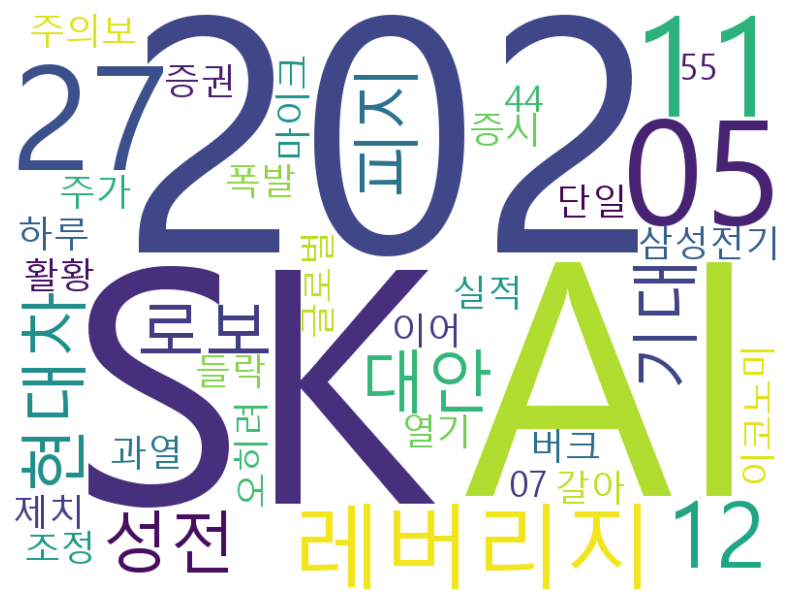

In [15]:
# 빈도수 기반으로 워드 클라우드 생성
cloud3 = wc.generate_from_frequencies(word_counts2)

plt.figure(figsize=(10, 8))
plt.imshow(cloud3, interpolation='bilinear')
plt.axis('off') # 축 눈금 숨기기
plt.show()